In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import shutil


# ============================================
# 1. RUTAS
# ============================================

BASE = Path('/content/drive/MyDrive/2026/proyecto_patrones/test')

OUTPUT = Path('/content/drive/MyDrive/2026/proyecto_patrones/preprocesadas')
COMPARATIVAS = Path('/content/drive/MyDrive/2026/proyecto_patrones/comparativas_antes_despues')
REPORTE = Path('/content/drive/MyDrive/2026/proyecto_patrones/reporte_preprocesamiento.csv')

CLASES = ['NORMAL', 'PNEUMONIA']
IMG_SIZE = 224


# ============================================
# 2. VERIFICACIÓN DE RUTAS
# ============================================

print("Ruta base existe:", BASE.exists())

for clase in CLASES:
    print(f"Carpeta {clase} existe:", (BASE / clase).exists())


# ============================================
# 3. FUNCIÓN PARA VALIDAR IMÁGENES
# ============================================

def validar_imagen(image_path):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        return False

    if img.size == 0:
        return False

    return True


# ============================================
# 4. FUNCIÓN DE PREPROCESAMIENTO
# ============================================

def preprocess_image(image_path):

    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    contrast = clahe.apply(resized)

    blurred = cv2.GaussianBlur(contrast, (3, 3), 0)

    normalized = blurred / 255.0

    processed = (normalized * 255).astype(np.uint8)

    return img, resized, contrast, blurred, normalized, processed


# ============================================
# 5. CONTEO Y VERIFICACIÓN DE IMÁGENES
# ============================================

reporte = []

for clase in CLASES:

    carpeta = BASE / clase
    archivos = list(carpeta.glob('*'))

    validas = 0
    danadas = 0

    for archivo in archivos:

        if validar_imagen(archivo):
            validas += 1
            estado = "válida"
        else:
            danadas += 1
            estado = "dañada"

        reporte.append({
            "clase": clase,
            "archivo": archivo.name,
            "ruta": str(archivo),
            "estado": estado
        })

    print(f"\nClase: {clase}")
    print(f"Total archivos: {len(archivos)}")
    print(f"Imágenes válidas: {validas}")
    print(f"Imágenes dañadas: {danadas}")


# Guardar reporte CSV
df_reporte = pd.DataFrame(reporte)
df_reporte.to_csv(REPORTE, index=False)

print("\nReporte guardado en:")
print(REPORTE)


# ============================================
# 6. GUARDAR IMÁGENES PREPROCESADAS
# ============================================

for clase in CLASES:

    input_folder = BASE / clase
    output_folder = OUTPUT / clase

    output_folder.mkdir(parents=True, exist_ok=True)

    archivos = list(input_folder.glob('*'))

    for archivo in archivos:

        if not validar_imagen(archivo):
            print(f"Imagen dañada omitida: {archivo}")
            continue

        _, _, _, _, _, processed = preprocess_image(archivo)

        save_path = output_folder / archivo.name

        cv2.imwrite(str(save_path), processed)

print("\nCarpeta final preprocesada creada en:")
print(OUTPUT)


# ============================================
# 7. GUARDAR COMPARATIVAS ANTES / DESPUÉS
# ============================================

def guardar_comparativa(image_path, clase):

    original, resized, contrast, blurred, normalized, processed = preprocess_image(image_path)

    output_folder = COMPARATIVAS / clase
    output_folder.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(18, 4))

    plt.subplot(1, 5, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 5, 2)
    plt.imshow(resized, cmap='gray')
    plt.title('Resize 224x224')
    plt.axis('off')

    plt.subplot(1, 5, 3)
    plt.imshow(contrast, cmap='gray')
    plt.title('CLAHE')
    plt.axis('off')

    plt.subplot(1, 5, 4)
    plt.imshow(blurred, cmap='gray')
    plt.title('Gaussian Blur')
    plt.axis('off')

    plt.subplot(1, 5, 5)
    plt.imshow(processed, cmap='gray')
    plt.title('Final')
    plt.axis('off')

    plt.suptitle(f'Comparativa - {clase}')
    plt.tight_layout()

    save_path = output_folder / f'comparativa_{image_path.stem}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

    return save_path


# Guardar 3 ejemplos por clase
for clase in CLASES:

    archivos_validos = [
        archivo for archivo in (BASE / clase).glob('*')
        if validar_imagen(archivo)
    ]

    for archivo in archivos_validos[:3]:
        ruta_guardada = guardar_comparativa(archivo, clase)
        print("Comparativa guardada:", ruta_guardada)


# ============================================
# 8. RESUMEN FINAL
# ============================================

print("\n===================================")
print("RESUMEN FINAL DEL PREPROCESAMIENTO")
print("===================================")

for clase in CLASES:
    total_original = len(list((BASE / clase).glob('*')))
    total_preprocesado = len(list((OUTPUT / clase).glob('*')))
    total_comparativas = len(list((COMPARATIVAS / clase).glob('*')))

    print(f"\nClase: {clase}")
    print(f"Originales: {total_original}")
    print(f"Preprocesadas: {total_preprocesado}")
    print(f"Comparativas antes/después: {total_comparativas}")

print("\nEntrega lista para el Integrante 4.")

Ruta base existe: True
Carpeta NORMAL existe: True
Carpeta PNEUMONIA existe: True

Clase: NORMAL
Total archivos: 234
Imágenes válidas: 234
Imágenes dañadas: 0

Clase: PNEUMONIA
Total archivos: 390
Imágenes válidas: 390
Imágenes dañadas: 0

Reporte guardado en:
/content/drive/MyDrive/2026/proyecto_patrones/reporte_preprocesamiento.csv

Carpeta final preprocesada creada en:
/content/drive/MyDrive/2026/proyecto_patrones/preprocesadas
Comparativa guardada: /content/drive/MyDrive/2026/proyecto_patrones/comparativas_antes_despues/NORMAL/comparativa_IM-0022-0001.png
Comparativa guardada: /content/drive/MyDrive/2026/proyecto_patrones/comparativas_antes_despues/NORMAL/comparativa_IM-0001-0001.png
Comparativa guardada: /content/drive/MyDrive/2026/proyecto_patrones/comparativas_antes_despues/NORMAL/comparativa_IM-0011-0001-0002.png
Comparativa guardada: /content/drive/MyDrive/2026/proyecto_patrones/comparativas_antes_despues/PNEUMONIA/comparativa_person109_bacteria_519.png
Comparativa guardada: /

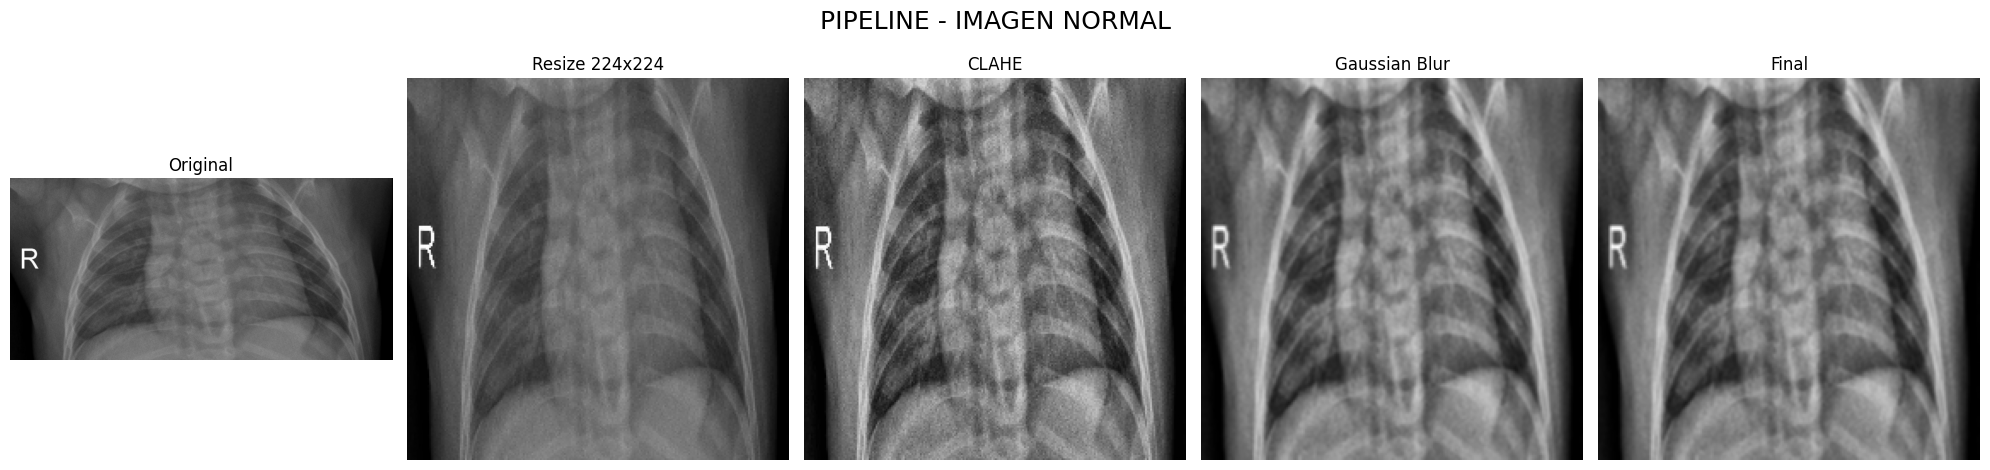

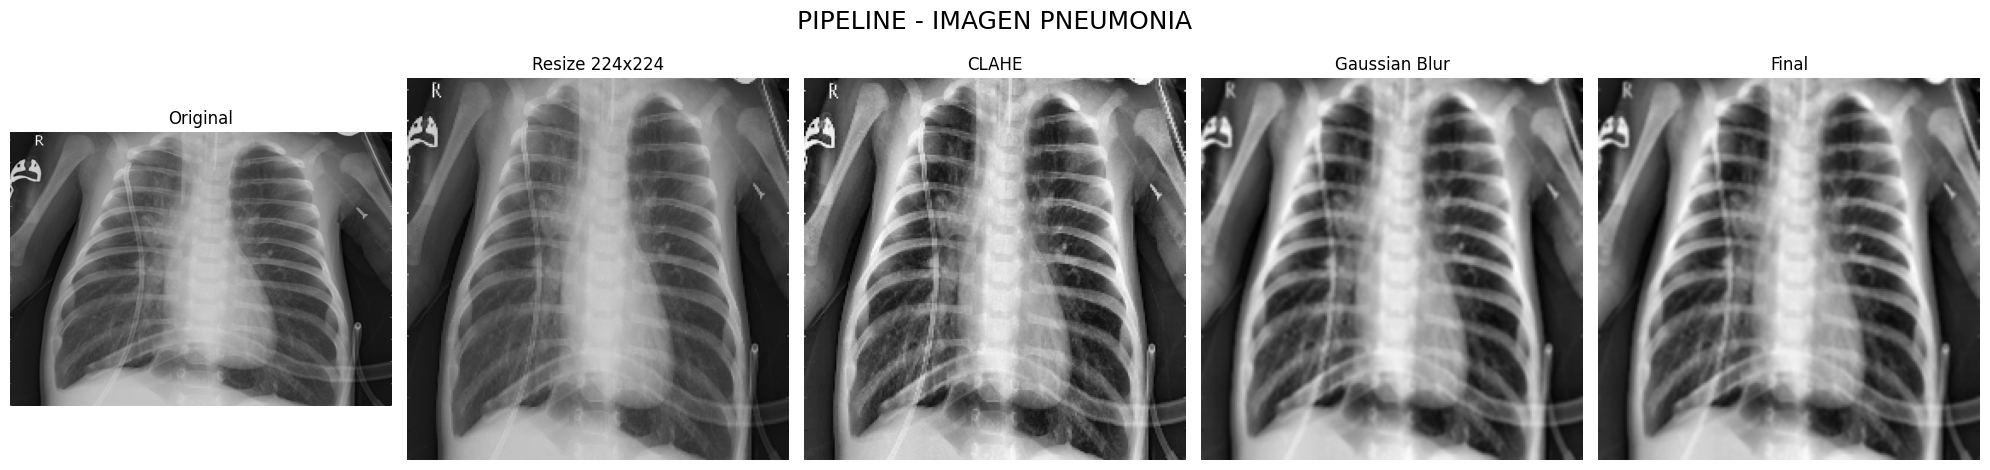

In [23]:
# ============================================
# VISUALIZACIÓN COMPLETA DEL PIPELINE
# ============================================

def mostrar_pipeline_completo(image_path, titulo):

    original, resized, contrast, blurred, normalized, processed = preprocess_image(image_path)

    etapas = [
        ("Original", original),
        ("Resize 224x224", resized),
        ("CLAHE", contrast),
        ("Gaussian Blur", blurred),
        ("Final", processed)
    ]

    fig, axes = plt.subplots(1, 5, figsize=(20,5))

    for ax, (nombre, imagen) in zip(axes, etapas):

        ax.imshow(imagen, cmap='gray')
        ax.set_title(nombre, fontsize=12)
        ax.axis('off')

    plt.suptitle(titulo, fontsize=18)

    plt.tight_layout()

    plt.show()


# ============================================
# MOSTRAR EJEMPLOS
# ============================================

normal_example = list((BASE / 'NORMAL').glob('*'))[0]
pneumonia_example = list((BASE / 'PNEUMONIA').glob('*'))[0]

mostrar_pipeline_completo(normal_example, "PIPELINE - IMAGEN NORMAL")

mostrar_pipeline_completo(pneumonia_example, "PIPELINE - IMAGEN PNEUMONIA")